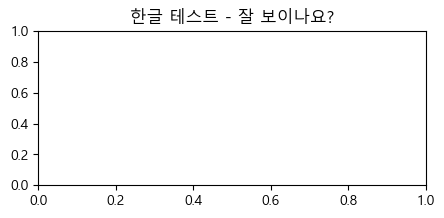

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_21260\1041321204.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='임신 성공 여부', data=train, palette='viridis')


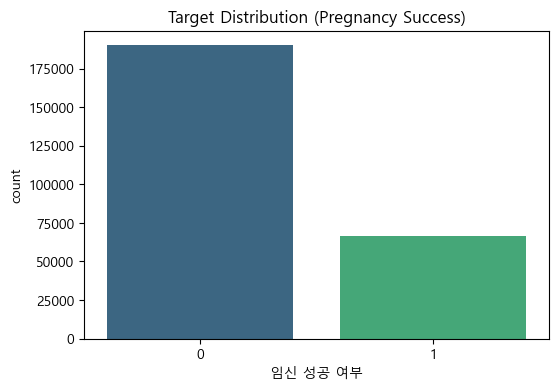

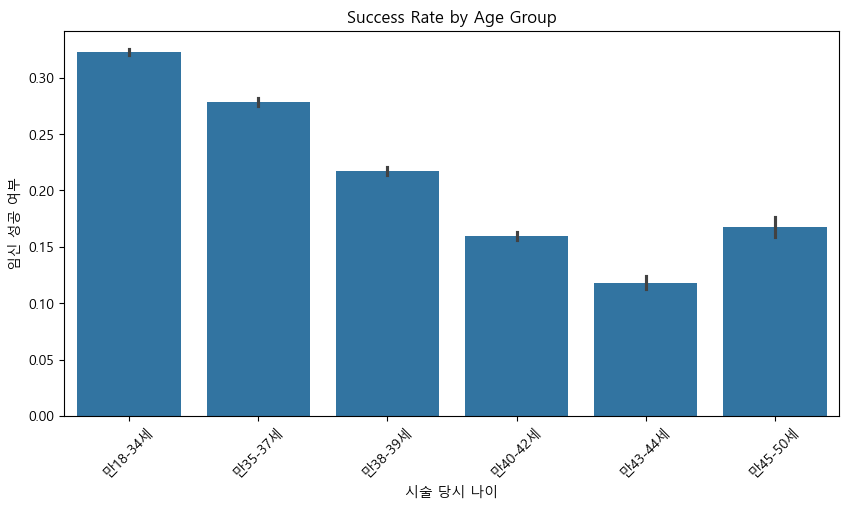

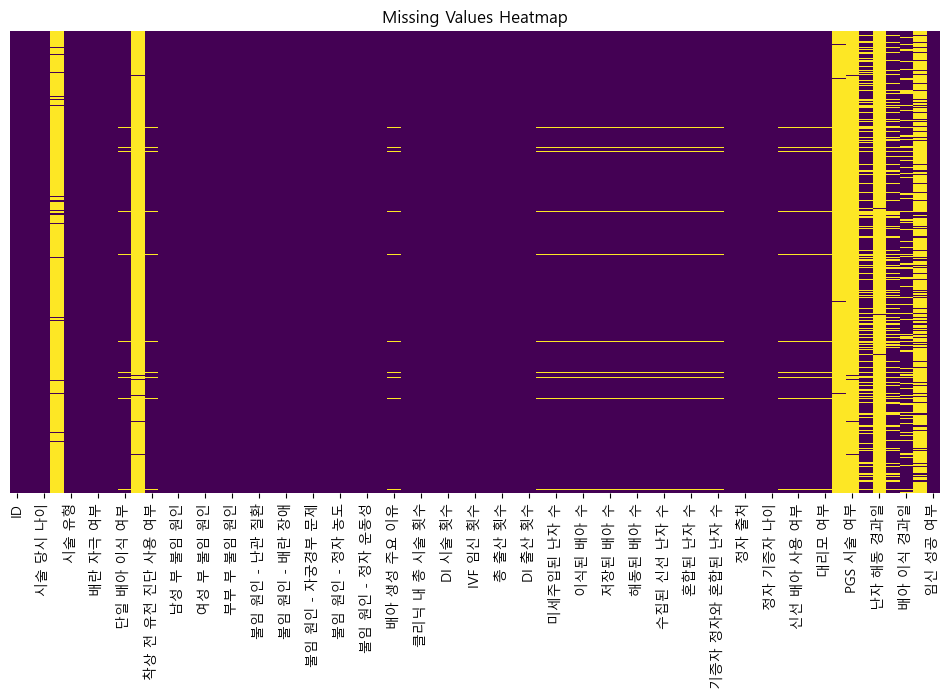

In [ ]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

# 1. OS에 따른 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin': # Mac
    plt.rcParams['font.family'] = 'AppleGothic'
else: # Linux (Colab 등)
    plt.rcParams['font.family'] = 'NanumGothic'

# 2. 마이너스 기호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False
##############################################################

# 1. 현재 폴더(notebooks)의 상위 폴더를 경로에 추가
sys.path.append(os.path.abspath(os.path.join('..')))

# 2. 우리가 만든 utils에서 함수 가져오기
from src.utils import get_data_path

# 3. 데이터 로드 (이제 경로 걱정 끝!)
# get_data_path가 내부적으로 '../data/raw/train.csv'를 찾을 수 있도록 
train = pd.read_csv(get_data_path("train.csv"))

# 2. 타겟 분포 확인 (성공률)
plt.figure(figsize=(6, 4))
sns.countplot(x='임신 성공 여부', data=train, palette='viridis')
plt.title('Target Distribution (Pregnancy Success)')
plt.show()

# 3. 나이대별 성공 확률 시각화 (가장 중요한 인사이트)
plt.figure(figsize=(10, 5))
sns.barplot(x='시술 당시 나이', y='임신 성공 여부', data=train, 
            order=['만18-34세', '만35-37세', '만38-39세', '만40-42세', '만43-44세', '만45-50세'])
plt.title('Success Rate by Age Group')
plt.xticks(rotation=45)
plt.show()

# 4. 결측치 히트맵 (어떤 데이터가 비어있는지 한눈에 보기)
plt.figure(figsize=(12, 6))
sns.heatmap(train.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()